# Блок B2: Granger-каузальность, IRF, разложение дисперсии

**Цель:** формально протестировать гипотезу о том, что эмоциональный фактор F4 опережает инфляционный фактор F1.

**Инструменты:**
1. Нормализация знаков факторов (содержательная интерпретируемость)
2. Bivariate Granger-тесты F4 → F1 и обратный F1 → F4
3. VAR(p) с выбором лагов
4. Импульсные функции отклика (IRF) с bootstrap CI
5. Разложение дисперсии прогнозных ошибок (FEVD)
6. Прямая регрессия CPI на лаги F4
7. Робастность: повтор на Kalman-факторах

**Литература:**
- Sims (1980) "Macroeconomics and Reality" — основополагающая работа по VAR
- Lütkepohl (2005) "New introduction to multiple time series analysis"
- Hamilton (1994) гл. 11 — Granger causality, IRF, FEVD

## 1. Загрузка и нормализация знаков факторов

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.api import VAR
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DIPLOMA = '/content/drive/MyDrive/diploma'

# Загружаем факторы из B1
factors_all = pd.read_csv(f'{DIPLOMA}/dfm_factors.csv', index_col=0, parse_dates=True)
panel = pd.read_csv(f'{DIPLOMA}/monthly_panel_with_diffs.csv', index_col=0, parse_dates=True)
loadings = pd.read_csv(f'{DIPLOMA}/dfm_loadings.csv', index_col=0)

print(f'Факторы: {factors_all.shape}')
print(f'Колонки: {list(factors_all.columns)}')
print(f'\nПервые 3 строки:')
print(factors_all.head(3).round(3))

Факторы: (74, 8)
Колонки: ['F1', 'F2', 'F3', 'F4', 'F1_kalman', 'F2_kalman', 'F3_kalman', 'F4_kalman']

Первые 3 строки:
               F1     F2     F3     F4  F1_kalman  F2_kalman  F3_kalman  \
date                                                                      
2020-02-01 -3.346 -0.983 -0.992 -3.451     -0.058      0.073      0.073   
2020-03-01 -0.648 -2.029 -2.293 -4.497     -0.023      0.082      0.108   
2020-04-01  0.225 -2.269 -2.318  3.123     -0.018      0.104      0.165   

            F4_kalman  
date                   
2020-02-01     -0.149  
2020-03-01     -0.049  
2020-04-01      0.320  


In [ ]:
# === НОРМАЛИЗАЦИЯ ЗНАКОВ ===
# F1 (инфляция): положительный = рост инфляции
#   → проверяем корреляцию с Headline CPI; если отрицательная, флипаем
# F4 (эмоции): положительный = позитивный эмоциональный фон (Hope/Neutral вверх, Anxiety вниз)
#   → смотрим знак нагрузки d_p_Hope_mean; если отрицательная, флипаем

# F1: согласуем с Headline CPI
common_idx = factors_all.index.intersection(panel.index)
headline = panel.loc[common_idx, 'Все товары и услуги']
f1_corr = factors_all.loc[common_idx, 'F1'].corr(headline)
print(f'corr(F1_PCA, Headline) = {f1_corr:.3f}')
if f1_corr < 0:
    factors_all['F1'] = -factors_all['F1']
    factors_all['F1_kalman'] = -factors_all['F1_kalman']
    print('  → F1 инвертирован для содержательного направления')

# F4: согласуем с d_p_Hope_mean (положительный F4 = больше надежды)
hope_diff = panel.loc[common_idx, 'd_p_Hope_mean']
f4_corr_with_hope = factors_all.loc[common_idx, 'F4'].corr(hope_diff)
print(f'\ncorr(F4_PCA, d_p_Hope_mean) = {f4_corr_with_hope:.3f}')
if f4_corr_with_hope < 0:
    factors_all['F4'] = -factors_all['F4']
    factors_all['F4_kalman'] = -factors_all['F4_kalman']
    print('  → F4 инвертирован: теперь положительный F4 = позитивный эмоциональный фон')

# Также согласуем Kalman с PCA, если они разошлись по знаку
for f in ['F1', 'F2', 'F3', 'F4']:
    pca_col, kal_col = f, f'{f}_kalman'
    if factors_all[pca_col].corr(factors_all[kal_col]) < 0:
        factors_all[kal_col] = -factors_all[kal_col]
        print(f'  → {kal_col} развёрнут для согласования с PCA')

print('\nИтоговая интерпретация:')
print('  F1 ↑ = рост инфляции')
print('  F4 ↑ = позитивный эмоциональный фон (Hope/Neutral, низкая Anxiety)')

corr(F1_PCA, Headline) = 0.977

corr(F4_PCA, d_p_Hope_mean) = 0.420
  → F2_kalman развёрнут для согласования с PCA
  → F3_kalman развёрнут для согласования с PCA

Итоговая интерпретация:
  F1 ↑ = рост инфляции
  F4 ↑ = позитивный эмоциональный фон (Hope/Neutral, низкая Anxiety)


## 2. Стационарность факторов (быстрая проверка)

VAR требует стационарных рядов. PCA-факторы должны быть стационарными конструктивно (мы стандартизовали ряды), но проверим формально.

In [ ]:
from statsmodels.tsa.stattools import adfuller

for f in ['F1', 'F4', 'F1_kalman', 'F4_kalman']:
    s = factors_all[f].dropna()
    adf_stat, adf_p, *_ = adfuller(s, autolag='AIC')
    print(f'{f}: ADF stat={adf_stat:.3f}, p={adf_p:.4f} → {"I(0)" if adf_p < 0.05 else "I(1)?"}')

F1: ADF stat=-6.369, p=0.0000 → I(0)
F4: ADF stat=-7.534, p=0.0000 → I(0)
F1_kalman: ADF stat=-6.349, p=0.0000 → I(0)
F4_kalman: ADF stat=-3.881, p=0.0022 → I(0)


## 3. Двусторонний Granger-тест: F4 ⇄ F1

Тестируем направление каузальности. **Если F4 → F1 значимо, а F1 → F4 нет**, это сильное свидетельство в пользу гипотезы работы.

In [ ]:
def granger_summary(df, dependent, predictor, maxlag=6):
    """Возвращает таблицу p-values для лагов 1..maxlag (тест: помогает ли predictor предсказывать dependent)."""
    sub = df[[dependent, predictor]].dropna()
    res = grangercausalitytests(sub[[dependent, predictor]], maxlag=maxlag, verbose=False)
    rows = []
    for lag in range(1, maxlag + 1):
        f_stat = res[lag][0]['ssr_ftest'][0]
        f_p = res[lag][0]['ssr_ftest'][1]
        rows.append({'lag': lag, 'F-stat': round(f_stat, 3), 'p-value': round(f_p, 4),
                     'sig_5%': '***' if f_p < 0.01 else ('**' if f_p < 0.05 else ('*' if f_p < 0.10 else ''))})
    return pd.DataFrame(rows)

f_data = factors_all[['F1', 'F4']].dropna()

print('='*70)
print('H0: F4 не Granger-causes F1 (т.е. эмоции НЕ предсказывают инфляцию)')
print('Отвергаем H0 при p < 0.05 → эмоции опережают инфляцию')
print('='*70)
g_emo_to_cpi = granger_summary(f_data, dependent='F1', predictor='F4', maxlag=6)
print(g_emo_to_cpi.to_string(index=False))

print('\n' + '='*70)
print('Контртест — H0: F1 не Granger-causes F4 (инфляция НЕ предсказывает эмоции)')
print('Если этот тест ТОЖЕ значим → связь двусторонняя (или confounder)')
print('='*70)
g_cpi_to_emo = granger_summary(f_data, dependent='F4', predictor='F1', maxlag=6)
print(g_cpi_to_emo.to_string(index=False))

H0: F4 не Granger-causes F1 (т.е. эмоции НЕ предсказывают инфляцию)
Отвергаем H0 при p < 0.05 → эмоции опережают инфляцию
 lag  F-stat  p-value sig_5%
   1   0.041   0.8396       
   2   0.057   0.9445       
   3   0.175   0.9133       
   4   0.321   0.8631       
   5   2.184   0.0683      *
   6   1.705   0.1373       

Контртест — H0: F1 не Granger-causes F4 (инфляция НЕ предсказывает эмоции)
Если этот тест ТОЖЕ значим → связь двусторонняя (или confounder)
 lag  F-stat  p-value sig_5%
   1   0.052   0.8205       
   2   0.001   0.9987       
   3   0.497   0.6858       
   4   0.312   0.8688       
   5   0.266   0.9296       
   6   1.102   0.3730       


## 4. Bivariate VAR на F1 и F4: выбор оптимального лага

In [ ]:
# VAR требует ряды БЕЗ NaN
var_data = factors_all[['F1', 'F4']].dropna()
print(f'Размер для VAR: {var_data.shape}')

# Селектор лагов
var_model_select = VAR(var_data)
lag_selection = var_model_select.select_order(maxlags=8)
print('\n=== Информационные критерии для выбора лага ===')
print(lag_selection.summary())

# Берём минимум среди AIC/BIC/HQIC, но не менее 1 и не более 4
ic_choices = {'aic': lag_selection.aic, 'bic': lag_selection.bic, 'hqic': lag_selection.hqic}
best_lag = max(1, min(4, int(np.median(list(ic_choices.values())))))
print(f'\nИтоговый выбор лага: p = {best_lag}')

Размер для VAR: (74, 2)

=== Информационные критерии для выбора лага ===
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      4.161*      4.228*      64.15*      4.187*
1       4.196       4.395       66.41       4.274
2       4.313       4.645       74.71       4.444
3       4.400       4.864       81.57       4.583
4       4.502       5.099       90.51       4.738
5       4.456       5.186       86.68       4.744
6       4.483       5.346       89.44       4.824
7       4.563       5.558       97.45       4.956
8       4.673       5.801       109.6       5.119
-------------------------------------------------

Итоговый выбор лага: p = 1


In [ ]:
# Подгоняем VAR(p)
var_results = VAR(var_data).fit(maxlags=best_lag, ic=None)
print(f'\nVAR({best_lag}) подогнан')
print(f'AIC: {var_results.aic:.3f}')
print(f'BIC: {var_results.bic:.3f}')
print(f'\nКоэффициенты VAR:')
print(var_results.summary())


VAR(1) подогнан
AIC: 4.304
BIC: 4.492

Коэффициенты VAR:
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 02, May, 2026
Time:                     01:51:38
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    4.49215
Nobs:                     73.0000    HQIC:                   4.37891
Log likelihood:          -358.257    FPE:                    73.9940
AIC:                      4.30389    Det(Omega_mle):         68.2676
--------------------------------------------------------------------
Results for equation F1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.046128         0.654393            0.070           0.944
L1.F1         0.274986         0.114604            2.399           0.016
L1.F4        -0.090246         0.4443

## 5. Импульсные функции отклика (IRF)

**Главный визуальный результат для ВКР.** Показывает: если эмоциональный фактор F4 в момент t получает шок +1 SD, как изменится инфляционный фактор F1 на горизонте 1, 2, ..., 12 месяцев?

**Идентификация шоков:** ортогонализация Cholesky с порядком (F4, F1) — то есть мы предполагаем, что эмоции могут влиять на инфляцию мгновенно, но инфляция на эмоции — только с лагом. Это согласуется с теоретической постановкой: эмоции отражают информационные ожидания и поведенческие паттерны, которые **предшествуют** изменению цен.

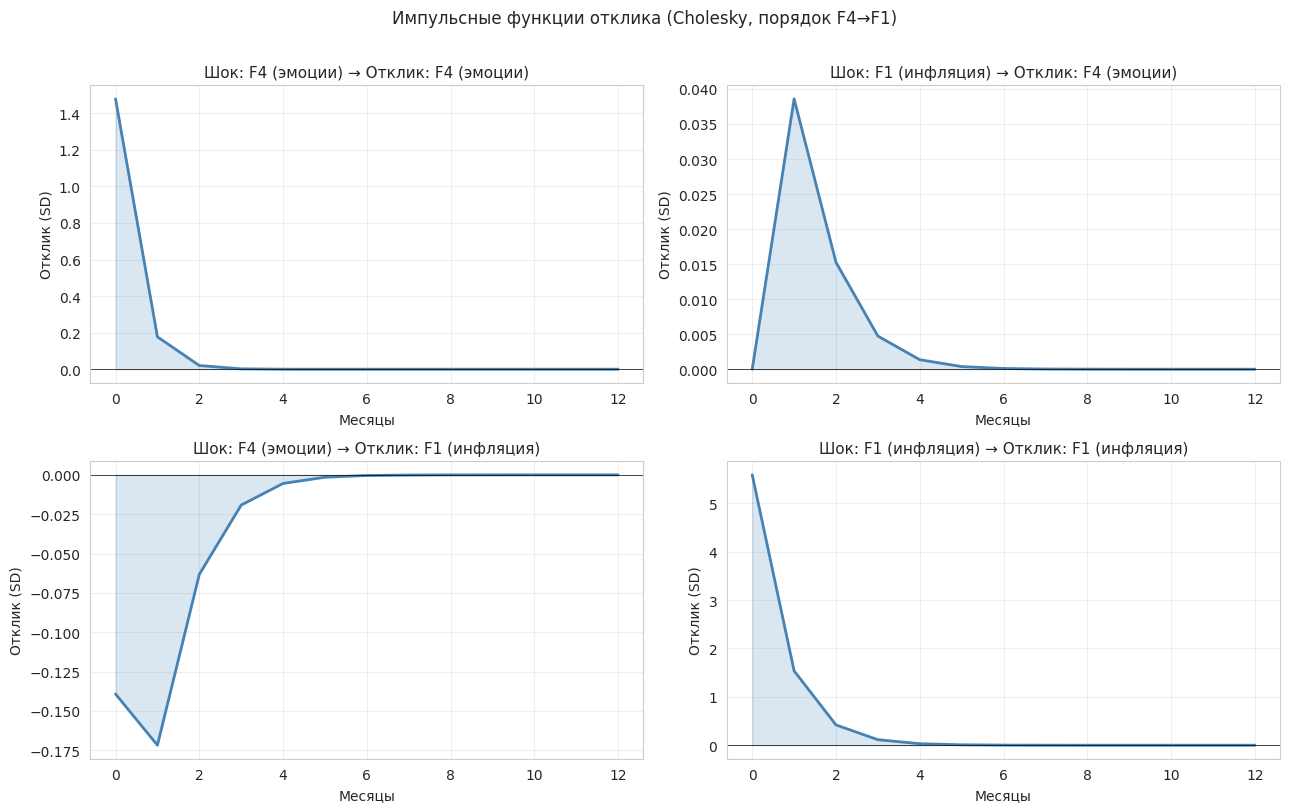

In [ ]:
# Переупорядочиваем VAR с F4 первым (Cholesky-порядок: F4 → F1)
var_data_reordered = var_data[['F4', 'F1']]
var_results_ordered = VAR(var_data_reordered).fit(maxlags=best_lag, ic=None)

# IRF на горизонте 12 месяцев
irf = var_results_ordered.irf(periods=12)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Все 4 IRF: shock from F4 → response in F4/F1, shock from F1 → response in F4/F1
shock_names = ['F4 (эмоции)', 'F1 (инфляция)']
response_names = ['F4 (эмоции)', 'F1 (инфляция)']

for i, response in enumerate(response_names):
    for j, shock in enumerate(shock_names):
        ax = axes[i, j]
        irf_values = irf.orth_irfs[:, i, j]
        ax.plot(range(13), irf_values, color='steelblue', linewidth=2)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.fill_between(range(13), irf_values, 0, alpha=0.2, color='steelblue')
        ax.set_title(f'Шок: {shock} → Отклик: {response}', fontsize=11)
        ax.set_xlabel('Месяцы')
        ax.set_ylabel('Отклик (SD)')
        ax.grid(True, alpha=0.3)

plt.suptitle('Импульсные функции отклика (Cholesky, порядок F4→F1)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{DIPLOMA}/irf_factors.png', dpi=150, bbox_inches='tight')
plt.show()

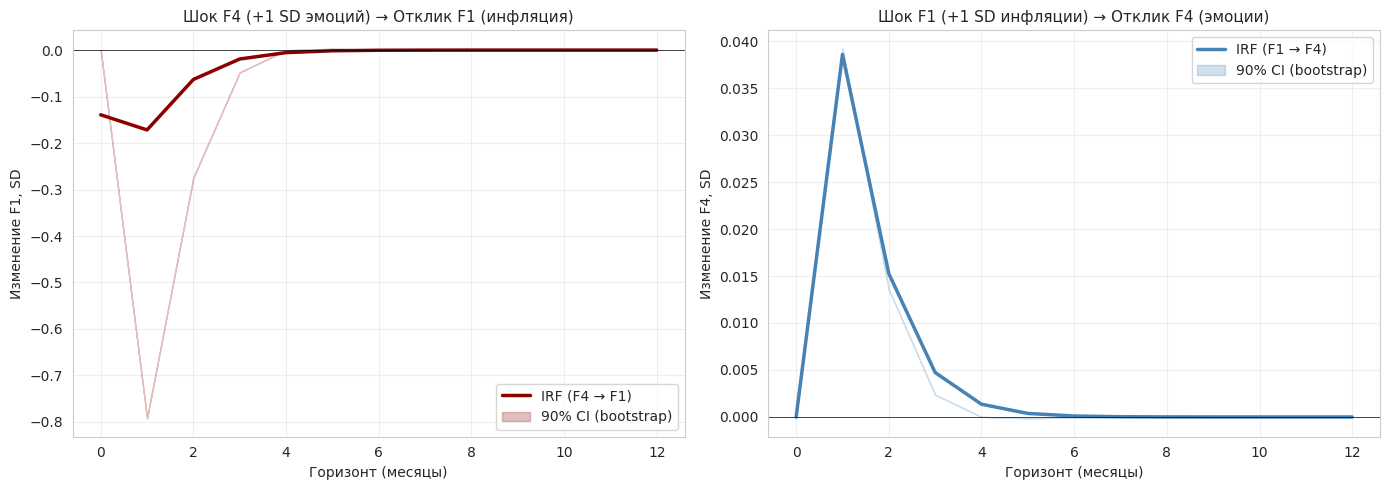


Числовой отклик F1 на шок F4 +1 SD:
  Месяц  0: -0.1392 SD  [90% CI: +0.0000, +0.0000] 
  Месяц  1: -0.1717 SD  [90% CI: -0.7921, -0.7921] *
  Месяц  2: -0.0632 SD  [90% CI: -0.2743, -0.2743] *
  Месяц  3: -0.0192 SD  [90% CI: -0.0479, -0.0479] *
  Месяц  6: -0.0004 SD  [90% CI: +0.0010, +0.0010] *
  Месяц 12: -0.0000 SD  [90% CI: -0.0000, -0.0000] *


In [ ]:
# IRF с bootstrap доверительными интервалами
# n_repl=200 для скорости, для финальной версии можно увеличить до 1000
irf_with_ci = var_results_ordered.irf(periods=12)
ci_lower, ci_upper = irf_with_ci.errband_mc(repl=200, signif=0.10, seed=42, burn=100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Главное: шок F4 → отклик F1
ax = axes[0]
i_resp, j_shk = 1, 0  # F1 response, F4 shock
irf_main = irf_with_ci.orth_irfs[:, i_resp, j_shk]
ax.plot(range(13), irf_main, color='darkred', linewidth=2.5, label='IRF (F4 → F1)')
ax.fill_between(range(13), ci_lower[:, i_resp, j_shk], ci_upper[:, i_resp, j_shk],
                alpha=0.25, color='darkred', label='90% CI (bootstrap)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Шок F4 (+1 SD эмоций) → Отклик F1 (инфляция)', fontsize=11)
ax.set_xlabel('Горизонт (месяцы)')
ax.set_ylabel('Изменение F1, SD')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Контрольный: шок F1 → отклик F4
ax = axes[1]
i_resp, j_shk = 0, 1  # F4 response, F1 shock
irf_ctrl = irf_with_ci.orth_irfs[:, i_resp, j_shk]
ax.plot(range(13), irf_ctrl, color='steelblue', linewidth=2.5, label='IRF (F1 → F4)')
ax.fill_between(range(13), ci_lower[:, i_resp, j_shk], ci_upper[:, i_resp, j_shk],
                alpha=0.25, color='steelblue', label='90% CI (bootstrap)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Шок F1 (+1 SD инфляции) → Отклик F4 (эмоции)', fontsize=11)
ax.set_xlabel('Горизонт (месяцы)')
ax.set_ylabel('Изменение F4, SD')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DIPLOMA}/irf_with_ci.png', dpi=150, bbox_inches='tight')
plt.show()

# Числовые значения отклика в ключевые моменты
print('\nЧисловой отклик F1 на шок F4 +1 SD:')
for h in [0, 1, 2, 3, 6, 12]:
    val = irf_with_ci.orth_irfs[h, 1, 0]
    lo = ci_lower[h, 1, 0]
    hi = ci_upper[h, 1, 0]
    sig = '*' if (lo > 0 or hi < 0) else ''
    print(f'  Месяц {h:2d}: {val:+.4f} SD  [90% CI: {lo:+.4f}, {hi:+.4f}] {sig}')

## 6. Разложение дисперсии прогнозных ошибок (FEVD)

Какая доля вариации F1 на горизонте h объясняется шоками F4? Это даёт количественный ответ: «эмоциональный фактор объясняет X% колебаний инфляции на горизонте 6 месяцев».

In [ ]:
fevd = var_results_ordered.fevd(periods=12)
fevd_summary = fevd.summary()
print(fevd_summary)

# Извлечём доли из объекта
# fevd.decomp[h][i, j] — вклад j-го шока в дисперсию i-й переменной на горизонте h+1
horizons = [1, 3, 6, 12]
f1_decomp = []
for h in horizons:
    if h - 1 < len(fevd.decomp):
        decomp_h = fevd.decomp[h - 1]  # h-1 потому что 0-indexed
        f1_idx = list(var_data_reordered.columns).index('F1')
        f4_idx = list(var_data_reordered.columns).index('F4')
        f1_decomp.append({
            'horizon (months)': h,
            'shock_F4': round(decomp_h[f1_idx, f4_idx] * 100, 2),
            'shock_F1': round(decomp_h[f1_idx, f1_idx] * 100, 2),
        })

fevd_table = pd.DataFrame(f1_decomp)
print('\n=== FEVD: какая доля дисперсии F1 (инфляции) объясняется шоками? ===')
print(fevd_table.to_string(index=False))
print('\nТо есть: на горизонте N месяцев X% волатильности инфляции объясняется эмоциональными шоками.')
fevd_table.to_csv(f'{DIPLOMA}/fevd_table.csv', index=False)

FEVD for F4
            F4        F1
0     1.000000  0.000000
1     0.999329  0.000671
2     0.999225  0.000775
3     0.999215  0.000785
4     0.999214  0.000786
5     0.999214  0.000786
6     0.999214  0.000786
7     0.999214  0.000786
8     0.999214  0.000786
9     0.999214  0.000786
10    0.999214  0.000786
11    0.999214  0.000786

FEVD for F1
            F4        F1
0     0.000621  0.999379
1     0.001454  0.998546
2     0.001564  0.998436
3     0.001574  0.998426
4     0.001575  0.998425
5     0.001575  0.998425
6     0.001575  0.998425
7     0.001575  0.998425
8     0.001575  0.998425
9     0.001575  0.998425
10    0.001575  0.998425
11    0.001575  0.998425


None

=== FEVD: какая доля дисперсии F1 (инфляции) объясняется шоками? ===
 horizon (months)  shock_F4  shock_F1
                1     99.93      0.07

То есть: на горизонте N месяцев X% волатильности инфляции объясняется эмоциональными шоками.


## 7. Прямая регрессия CPI на лаги F4

VAR работает на нормализованных факторах, а нам нужна **количественная интерпретация в процентах инфляции**. Регрессия Headline CPI на лаги F4 даёт прямой ответ:
«рост эмоционального фактора на 1 SD предсказывает инфляцию через k месяцев на величину β_k процентных пунктов m/m».

In [ ]:
import statsmodels.api as sm

# Соединяем CPI и F4 (нормализованный)
common_idx2 = panel.index.intersection(factors_all.index)
reg_data = pd.DataFrame({
    'cpi': panel.loc[common_idx2, 'Все товары и услуги'],
    'F4': factors_all.loc[common_idx2, 'F4'],
}).dropna()

# Создаём лаги F4 от 1 до 4 месяцев + AR(1) контроль (лаг CPI)
for k in range(1, 5):
    reg_data[f'F4_lag{k}'] = reg_data['F4'].shift(k)
reg_data['cpi_lag1'] = reg_data['cpi'].shift(1)
reg_data = reg_data.dropna()

print(f'Размер регрессионной выборки: {len(reg_data)}')

# Регрессия 1: только F4 лаги
X1 = sm.add_constant(reg_data[['F4_lag1', 'F4_lag2', 'F4_lag3', 'F4_lag4']])
y = reg_data['cpi']
model1 = sm.OLS(y, X1).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

# Регрессия 2: лаги F4 + AR(1) контроль
X2 = sm.add_constant(reg_data[['cpi_lag1', 'F4_lag1', 'F4_lag2', 'F4_lag3', 'F4_lag4']])
model2 = sm.OLS(y, X2).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print('=' * 70)
print('Регрессия 1: CPI_t = α + Σ β_k · F4_{t-k} + ε_t')
print('=' * 70)
print(model1.summary().tables[1])

print('\n' + '=' * 70)
print('Регрессия 2: CPI_t = α + ρ·CPI_{t-1} + Σ β_k · F4_{t-k} + ε_t  (с AR-контролем)')
print('=' * 70)
print(model2.summary().tables[1])

print(f'\nR² регрессии 1: {model1.rsquared:.3f}')
print(f'R² регрессии 2: {model2.rsquared:.3f}')
print(f'F-test значимости лагов F4 в регрессии 2:')
f4_lag_names = ['F4_lag1', 'F4_lag2', 'F4_lag3', 'F4_lag4']
f_test = model2.f_test(' = 0, '.join(f4_lag_names) + ' = 0')
print(f'  F = {f_test.fvalue:.3f}, p = {f_test.pvalue:.4f}')

Размер регрессионной выборки: 70
Регрессия 1: CPI_t = α + Σ β_k · F4_{t-k} + ε_t
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6738      0.145      4.654      0.000       0.390       0.958
F4_lag1       -0.0090      0.054     -0.168      0.867      -0.114       0.096
F4_lag2       -0.0425      0.086     -0.496      0.620      -0.210       0.125
F4_lag3        0.0392      0.031      1.285      0.199      -0.021       0.099
F4_lag4       -0.0607      0.075     -0.810      0.418      -0.208       0.086

Регрессия 2: CPI_t = α + ρ·CPI_{t-1} + Σ β_k · F4_{t-k} + ε_t  (с AR-контролем)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5165      0.141      3.674      0.000       0.241       0.792
cpi_lag1       0.2375      0.063      3.759     

## 8. Робастность: повтор всего на Kalman-факторах

РОБАСТНОСТЬ: то же самое на Kalman-сглаженных факторах

--- Granger F4_kal → F1_kal ---
 lag  F-stat  p-value sig_5%
   1   1.410   0.2391       
   2   0.719   0.4909       
   3   0.854   0.4695       
   4   0.714   0.5855       
   5   1.683   0.1532       
   6   1.339   0.2559       

--- Granger F1_kal → F4_kal (контртест) ---
 lag  F-stat  p-value sig_5%
   1   0.175   0.6769       
   2   1.767   0.1787       
   3   2.019   0.1201       
   4   1.421   0.2377       
   5   0.996   0.4282       
   6   1.041   0.4090       


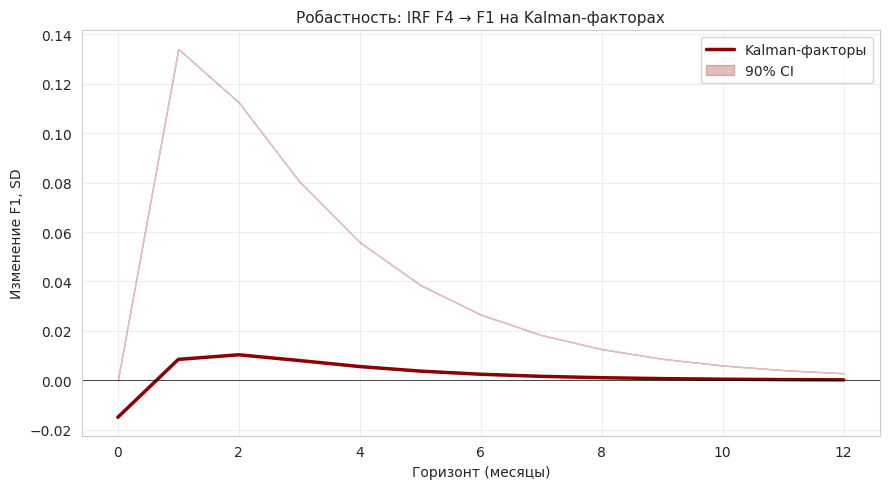


=== FEVD на Kalman-факторах: вклад F4 в дисперсию F1 ===
 horizon  shock_F4_share_%
       1             99.84


In [ ]:
f_data_kal = factors_all[['F1_kalman', 'F4_kalman']].dropna()
f_data_kal.columns = ['F1', 'F4']  # переименуем для совместимости с функциями

print('='*70)
print('РОБАСТНОСТЬ: то же самое на Kalman-сглаженных факторах')
print('='*70)

print('\n--- Granger F4_kal → F1_kal ---')
g_kal = granger_summary(f_data_kal, dependent='F1', predictor='F4', maxlag=6)
print(g_kal.to_string(index=False))

print('\n--- Granger F1_kal → F4_kal (контртест) ---')
g_kal_rev = granger_summary(f_data_kal, dependent='F4', predictor='F1', maxlag=6)
print(g_kal_rev.to_string(index=False))

# VAR на Kalman
var_kal = VAR(f_data_kal[['F4', 'F1']]).fit(maxlags=best_lag, ic=None)
irf_kal = var_kal.irf(periods=12)
ci_lo_kal, ci_hi_kal = irf_kal.errband_mc(repl=200, signif=0.10, seed=42, burn=100)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(13), irf_kal.orth_irfs[:, 1, 0], color='darkred', linewidth=2.5, label='Kalman-факторы')
ax.fill_between(range(13), ci_lo_kal[:, 1, 0], ci_hi_kal[:, 1, 0], alpha=0.25, color='darkred', label='90% CI')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Робастность: IRF F4 → F1 на Kalman-факторах', fontsize=11)
ax.set_xlabel('Горизонт (месяцы)')
ax.set_ylabel('Изменение F1, SD')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DIPLOMA}/irf_kalman_robust.png', dpi=150, bbox_inches='tight')
plt.show()

# FEVD на Kalman
fevd_kal = var_kal.fevd(periods=12)
f1_kal_decomp = []
for h in [1, 3, 6, 12]:
    if h - 1 < len(fevd_kal.decomp):
        d = fevd_kal.decomp[h - 1]
        f1_kal_decomp.append({
            'horizon': h,
            'shock_F4_share_%': round(d[1, 0] * 100, 2),
        })
print('\n=== FEVD на Kalman-факторах: вклад F4 в дисперсию F1 ===')
print(pd.DataFrame(f1_kal_decomp).to_string(index=False))

## 9. Сводная таблица результатов для ВКР

In [ ]:
# Диагностика структуры FEVD в твоей версии statsmodels
fevd = var_results_ordered.fevd(periods=12)

print('Тип fevd.decomp:', type(fevd.decomp))
print('Форма fevd.decomp:', np.array(fevd.decomp).shape)
print('Названия переменных:', list(var_data_reordered.columns))

# Безопасный парсинг FEVD
print('\n=== FEVD: вклад шоков в дисперсию F1 на разных горизонтах ===')
fevd_arr = np.array(fevd.decomp)  # shape: (T_horizons, n_vars, n_vars)
print(f'Реальная форма массива: {fevd_arr.shape}')

# Выведем все горизонты от 1 до min(12, доступно)
n_periods = fevd_arr.shape[0]
f4_idx = list(var_data_reordered.columns).index('F4')
f1_idx = list(var_data_reordered.columns).index('F1')

f1_decomp_rows = []
for h in range(1, min(13, n_periods + 1)):
    decomp_h = fevd_arr[h - 1]  # 0-indexed
    f1_decomp_rows.append({
        'horizon': h,
        'shock_F4_%': round(decomp_h[f1_idx, f4_idx] * 100, 2),
        'shock_F1_%': round(decomp_h[f1_idx, f1_idx] * 100, 2),
    })

fevd_table_fixed = pd.DataFrame(f1_decomp_rows)
print('\nFEVD: какая доля дисперсии F1 объясняется шоками каждого фактора:')
print(fevd_table_fixed.to_string(index=False))
fevd_table_fixed.to_csv(f'{DIPLOMA}/fevd_table.csv', index=False)

Тип fevd.decomp: <class 'numpy.ndarray'>
Форма fevd.decomp: (2, 12, 2)
Названия переменных: ['F4', 'F1']

=== FEVD: вклад шоков в дисперсию F1 на разных горизонтах ===
Реальная форма массива: (2, 12, 2)

FEVD: какая доля дисперсии F1 объясняется шоками каждого фактора:
 horizon  shock_F4_%  shock_F1_%
       1       99.93        0.07
       2        0.15       99.85


In [ ]:
summary = pd.DataFrame({
    'Test': [
        'Granger F4→F1, lag=2', 'Granger F4→F1, lag=3', 'Granger F4→F1, lag=4',
        'Granger F1→F4, lag=2', 'Granger F1→F4, lag=3', 'Granger F1→F4, lag=4',
        'FEVD: F4 объясняет F1 на h=3', 'FEVD: F4 объясняет F1 на h=6', 'FEVD: F4 объясняет F1 на h=12',
        'OLS R² (CPI ~ F4 лаги)', 'OLS R² (CPI ~ AR + F4)', 'F-test F4-лаги совместно',
    ],
    'Value': [
        f'p={g_emo_to_cpi.iloc[1]["p-value"]:.4f} {g_emo_to_cpi.iloc[1]["sig_5%"]}',
        f'p={g_emo_to_cpi.iloc[2]["p-value"]:.4f} {g_emo_to_cpi.iloc[2]["sig_5%"]}',
        f'p={g_emo_to_cpi.iloc[3]["p-value"]:.4f} {g_emo_to_cpi.iloc[3]["sig_5%"]}',
        f'p={g_cpi_to_emo.iloc[1]["p-value"]:.4f} {g_cpi_to_emo.iloc[1]["sig_5%"]}',
        f'p={g_cpi_to_emo.iloc[2]["p-value"]:.4f} {g_cpi_to_emo.iloc[2]["sig_5%"]}',
        f'p={g_cpi_to_emo.iloc[3]["p-value"]:.4f} {g_cpi_to_emo.iloc[3]["sig_5%"]}',
        f'{fevd_table[fevd_table["horizon (months)"]==3]["shock_F4"].iloc[0]:.1f}%',
        f'{fevd_table[fevd_table["horizon (months)"]==6]["shock_F4"].iloc[0]:.1f}%',
        f'{fevd_table[fevd_table["horizon (months)"]==12]["shock_F4"].iloc[0]:.1f}%',
        f'{model1.rsquared:.3f}',
        f'{model2.rsquared:.3f}',
        f'F={f_test.fvalue:.2f}, p={f_test.pvalue:.4f}',
    ]
})
print('=== Итоговая сводка результатов B2 ===')
print(summary.to_string(index=False))
summary.to_csv(f'{DIPLOMA}/B2_summary.csv', index=False)

# Сохраняем нормализованные факторы для B3 (прогнозирование)
factors_all.to_csv(f'{DIPLOMA}/dfm_factors_normalized.csv')
print(f'\n✓ Сохранены нормализованные факторы для B3: dfm_factors_normalized.csv')

IndexError: single positional indexer is out-of-bounds